In [ ]:
import os

experiment_name = 'sac_c10+n-10_b100'

eval_data_path = os.path.join('experiments',experiment_name,'eval_data.csv')

In [4]:
import pandas as pd

df = pd.read_csv(eval_data_path)
rewards = []
experiment_numbers = []
index_value = df.index[df['timestep'] == 0].tolist()

for i in range(len(index_value)):
    if i != len(index_value) - 1:
        start_index = index_value[i]
        end_index = index_value[i + 1] - 1

        subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
        reward_sum = subset_df['reward'].sum()
        rewards.append(reward_sum)
        experiment_number = subset_df['experiment_number'].iloc[0]
        experiment_numbers.append(experiment_number)

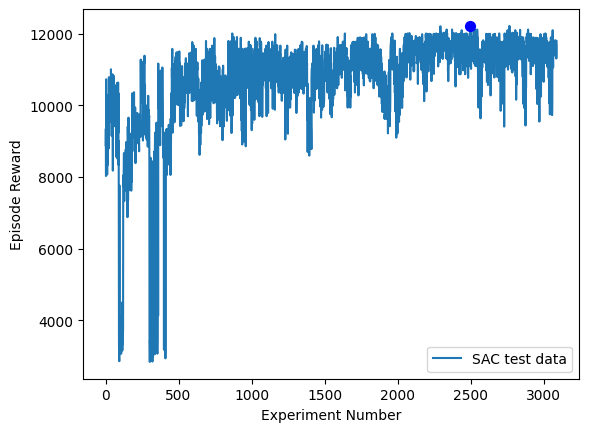

In [43]:
import matplotlib.pyplot as plt

plt.scatter(rewards.index(max(rewards)), max(rewards), color='blue', marker='o', s=50,  zorder=3)
plt.plot(experiment_numbers, rewards, label='SAC test data')
plt.xlabel("Experiment Number")
plt.ylabel("Episode Reward")

# Find the index where the maximum reward occurs
max_reward_index = rewards.index(max(rewards))

# Add the vertical line at max_reward_index, extending from Y=0 to Y=max(rewards)
#plt.axvline(x=max_reward_index, color='red', ymin=0, ymax=10000)

plt.legend()
plt.show()

